In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pymysql

db = pymysql.connect(
    host="127.0.0.1",
    user="root",
    password="shraddha17",
    database="ecommerce"
)

cur = db.cursor()

In [4]:
cursor = db.cursor()

cursor.execute("SHOW TABLES")

for table in cursor:
    print(table)

('amazons',)
('cloud',)
('expense_gf',)
('international_sale_report',)
('may',)
('sale_report',)


# List all unique categories.



In [3]:
query = """select distinct category  from amazons"""
cur.execute(query)
data = cur.fetchall()
data
df = pd.DataFrame(data)
df.head(10)

,0
0,Set
1,kurta
2,Western Dress
3,Top


# count the number of orders placed in jul 21

In [16]:
query = """select count(CUSTOMER) from international_sale_report where Months = 'Jul-21' """
cur.execute(query)
data = cur.fetchall()
data

((393,),)

# Find the total sales per category

In [5]:
query = """select sum(Weight) from may where Category = 'Kurta'"""
cur.execute(query)
data = cur.fetchall()
data

((4.799999999999999,),)

In [10]:
query = """SELECT a.Category,
                i.Rate
FROM amazon as a INNER JOIN international_sale_report AS i
ON a.SKU = i.SKU ; """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['Category','Sales'])
df

,Category,Sales
0,Western Dress,747.00
1,kurta,389.35
2,kurta,389.35
3,Set,1234.00
4,kurta,389.35
...,...,...
246,Western Dress,812.00
247,Set,1169.35
248,Set,1494.35
249,Set,1494.35


# Count number of orders based on satus

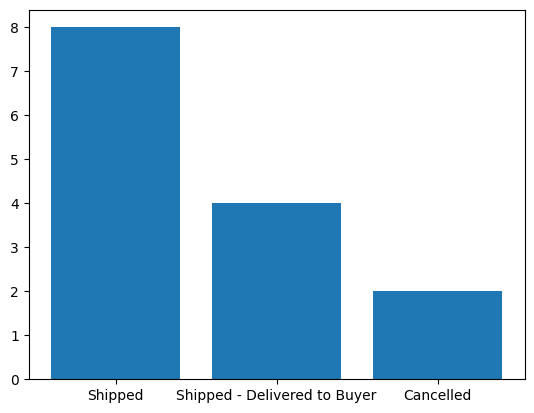

In [31]:
query = """select status , count(Order_ID) from amazons group by status """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["status" ,"Order"])
df = df.sort_values(by = "Order" ,ascending=False)
plt.bar(df["status"] , df["Order"])
plt.show()


In [10]:
query = """select month(Date) months, count(Order_ID) order_count from amazons where(Date) = 2022
group by months """
cur.execute(query)
data = cur.fetchall()
data

()

# find the avg number of stock per category grouped by size

In [15]:
query = """select  Size, avg (Stock) as Avg_stock from sale_report 
where Category  = 'AN : LEGGINGS'
group by Size"""
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns =["Size","Stock"])
df

,Size,Stock
0,L,8.0
1,M,4.0
2,S,9.5
3,XL,7.0
4,XXL,8.5


# calculate the percentage ot total revenue contibuted by each product category

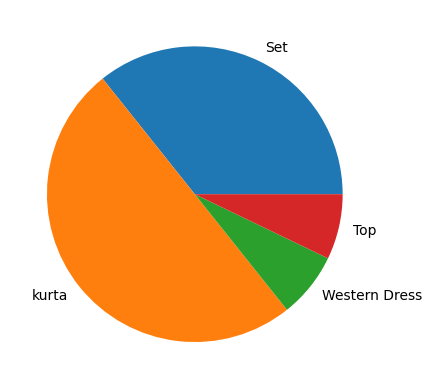

In [24]:
query = """SELECT a.Category,
               sum(i.Gross_amt) as total_revenue,
               round(
                    (sum(i.Gross_amt)*100.0) / 
                    (select sum(Gross_amt) from  international_sale_report),
                    2
                )as Revenue_Percentage
FROM amazons as a INNER JOIN international_sale_report AS i
ON a.`index` = i.`index` 
group by a.Category; """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['Category','Total_Revenue' , 'Rveenue%'])
plt.pie(df['Rveenue%'] , labels = df['Category'])
plt.show()

# Identify the relation btw product price and number of times a product has been purchased

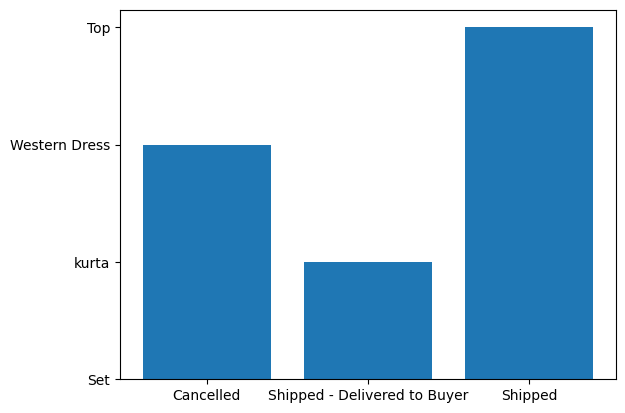

In [12]:
query = """SELECT a.Status,Category,
                i.RATE
FROM amazons as a INNER JOIN international_sale_report AS i
ON a.`index` = i.`index` ; """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['Status','Category','Rate'])
plt.bar(df["Status"] , df["Category"])
plt.show()

# Calculate the total rate generated by each order , and rank them by rate

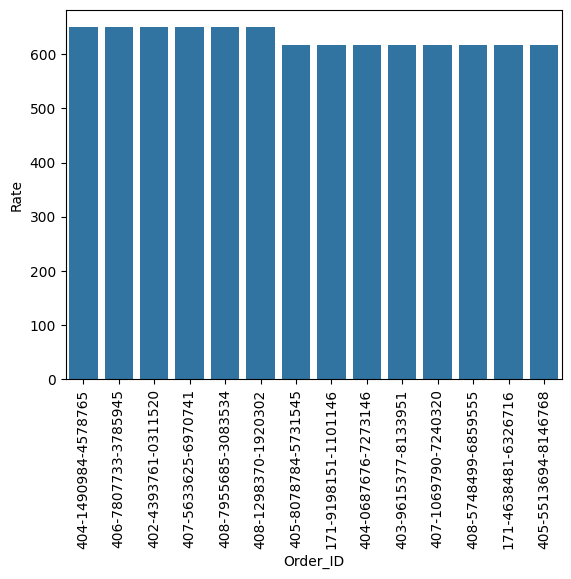

In [20]:
query = """SELECT a.Order_ID,
                i.RATE,
                RANK() OVER (ORDER BY i.RATE DESC) AS Rate_Rank
FROM amazons as a INNER JOIN international_sale_report AS i
ON a.`index` = i.`index` ; """
cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ['Order_ID','Rate','Rank'])
sns.barplot(x="Order_ID",y="Rate" , data = df)
plt.xticks(rotation = 90)
plt.show()
